# Teoria por trás da geração de espectros sintéticos (XRF e Vis–NIR)

**Resumo:** Criamos espectros sintéticos modelando cada espectro como a soma de picos Gaussianos (cada pico representando uma contribuição espectral localizada) mais ruído de base. Aplicações comuns: **XRF** (linhas de emissão elementares, tipicamente estreitas) e **Vis–NIR** (bandas de absorção vibronicamente alargadas). A estratégia reproduz propriedades físicas e estatísticas observadas em espectros reais: linhas ou bandas com formas aproximadamente Gaussianas devido a efeitos instrumentais e broadening, variação de amplitude/largura entre amostras e ruído instrumental/ambiental.

## Fundamentos para XRF e Vis–NIR
- **XRF**: apresenta picos estreitos (linhas de emissão) associados a transições eletrônicas de elementos; a largura observada é muitas vezes dominada pela resolução instrumental e pode ser aproximada por uma função Gaussiana.
- **Vis–NIR**: apresenta bandas de absorção mais largas (vibrações, combinações e sobretons) que se sobrepõem; aproximações gaussianas ou Voigt ajudam a representar sua forma.
- A **linearidade** da superposição permite construir espectros complexos somando picos simples; isso torna o modelo altamente interpretável.
- **Variabilidade natural** e **ruído** são modelados para reproduzir dispersão e SNR típicos de medições reais.

## Equações matemáticas
- Pico Gaussiano (parâmetros: amplitude $A$, centro $c$, largura $\sigma$):
$$
g(x) = A \exp\!\left(-\frac{(x - c)^2}{2\sigma^2}\right)
$$
- Espectro como soma de picos + ruído:
$$
S(x) = \sum_{i} A_i \exp\!\left(-\frac{(x - c_i)^2}{2\sigma_i^2}\right) + \varepsilon(x),
$$
onde $\varepsilon(x)$ representa ruído de base (por exemplo, ruído gaussiano branco).

## Por que esse modelo funciona
1. **Picos Gaussianos**: a forma Gaussiana captura broadening instrumental e muitos efeitos de dispersão; para XRF a largura é pequena (linhas afiadas), para Vis–NIR $\sigma$ tende a ser maior (bandas largas).
2. **Soma linear**: a assinatura espectral resultante é interpretável como contribuições separadas (elementos ou modos vibracionais).
3. **Variação estatística**: amostrar $A_i$ e $\sigma_i$ por amostra imita variabilidade real entre medições.
4. **Ruído**: adiciona realismo e evita separações triviais que não existem em dados experimentais.

## Parâmetros importantes e seus efeitos
- **Resolução (n_points)**: em XRF, é necessário resolver linhas estreitas; em Vis–NIR, bandas largas podem ser capturadas com resoluções menores.
- **SNR (desvio do ruído)**: ruído maior reduz detectabilidade de picos fracos.
- **Distribuições de $A_i$ e $\sigma_i$**: controlam quão separáveis são as classes e quão realistas são as variações.

## Limitações e extensões
- Para **XRF**, linhas podem apresentar assimetria ou múltiplos componentes — considerar modelo Gaussiano + cauda (ou funções empíricas).
- Para **Vis–NIR**, bandas superpostas podem exigir Voigt ou modelos empíricos para melhor ajuste.
- Extensões úteis: baseline não estacionária, ruído correlacionado, deslocamentos de centro, convolução com resposta instrumental.

---

### Guia rápido do código
- `modelo_pico`: implementa um pico Gaussiano simples (veja a equação acima).
- `gerar_dados_espectrais`: cria espectros por classe somando picos e ruído; retorna `x, X, y`.
- No exemplo do notebook, a diferença entre classes é ilustrada pela presença/ausência de um pico (pense em uma linha XRF ausente para um elemento ou uma banda Vis–NIR ausente/forte para um composto).

> Nota: mantenha unidades claras — em XRF use energia (keV) ou canal, em Vis–NIR use comprimento de onda (nm); o eixo `x` do código é genérico e pode ser interpretado conforme a aplicação.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# FUNÇÕES AUXILIARES
# =============================================================================

def modelo_pico_gaussiano(x, centro, amplitude, largura):
    """
    Gera um pico Gaussiano unidimensional.
    
    A função implementa a equação:
    g(x) = A * exp(-(x - c)² / (2σ²))
    
    Parâmetros
    ----------
    x : array_like
        Eixo espectral (comprimentos de onda, energia, canais)
    centro : float
        Posição central do pico (mesma unidade de x)
    amplitude : float
        Altura máxima do pico (intensidade no centro)
    largura : float
        Desvio padrão (σ) do pico — controla a dispersão/largura
        
    Retorna
    -------
    ndarray
        Array com o pico Gaussiano avaliado em cada ponto de x
        
    Notas
    -----
    - Para XRF: usar largura pequena (~5-15) para simular linhas estreitas
    - Para Vis-NIR: usar largura maior (~20-50) para bandas largas
    """
    return amplitude * np.exp(-(x - centro)**2 / (2 * largura**2))


def _gerar_espectro_unico(
    x, 
    centros_picos, 
    amp_media=1.0, 
    amp_std=0.1, 
    larg_media=15.0, 
    larg_std=2.0, 
    ruido_std=0.02
):
    """
    Gera um único espectro somando picos Gaussianos com variabilidade + ruído.
    
    Função auxiliar interna para gerar_dados_espectrais_sinteticos.
    
    Parâmetros
    ----------
    x : ndarray
        Eixo espectral
    centros_picos : list of float
        Posições dos picos a serem adicionados
    amp_media, amp_std : float
        Média e desvio padrão da amplitude dos picos
    larg_media, larg_std : float
        Média e desvio padrão da largura dos picos
    ruido_std : float
        Desvio padrão do ruído gaussiano de linha de base
        
    Retorna
    -------
    ndarray
        Espectro sintético (linha de base + picos)
    """
    # Linha de base: ruído branco gaussiano
    espectro = np.random.normal(0, ruido_std, len(x))
    
    # Adicionar cada pico com variabilidade aleatória
    for centro in centros_picos:
        amp = np.random.normal(amp_media, amp_std)
        larg = np.random.normal(larg_media, larg_std)
        espectro += modelo_pico_gaussiano(x, centro, amp, larg)
    
    return espectro


# =============================================================================
# FUNÇÃO PRINCIPAL (MULTI-CLASSE)
# =============================================================================

def gerar_dados_espectrais_sinteticos(
    configuracao_classes,
    n_pontos=500,
    x_min=0,
    x_max=1000,
    seed=None
):
    """
    Gera conjunto de espectros sintéticos para múltiplas classes (N classes).
    
    Retorna um DataFrame onde:
    - Primeira coluna: 'classe' (valores definidos pelo usuário: 'A', 'B', 'C', ...)
    - Demais colunas: variáveis espectrais (valores de intensidade)
    - Linhas: amostras individuais
    
    Parâmetros
    ----------
    configuracao_classes : list of dict
        Lista de dicionários, onde cada dicionário define uma classe com:
        - 'nome': str, nome da classe (ex: 'A', 'B', 'Classe1', etc.)
        - 'n_amostras': int, número de amostras para esta classe
        - 'picos': list of float, posições dos picos no eixo espectral
        - 'amp_media': float, optional (default=1.0), média da amplitude dos picos
        - 'amp_std': float, optional (default=0.1), desvio padrão da amplitude
        - 'larg_media': float, optional (default=15.0), média da largura dos picos
        - 'larg_std': float, optional (default=2.0), desvio padrão da largura
        - 'ruido_std': float, optional (default=0.02), desvio padrão do ruído de base
        
        Exemplo:
        [
            {
                'nome': 'A',
                'n_amostras': 50,
                'picos': [250, 550, 700, 850],
                'amp_media': 1.0,
                'larg_media': 15.0
            },
            {
                'nome': 'B',
                'n_amostras': 50,
                'picos': [250, 700, 850],
                'amp_media': 1.2,
                'larg_media': 20.0
            }
        ]
        
    n_pontos : int, default=500
        Número de pontos no eixo espectral (resolução)
    x_min, x_max : float, default=0, 1000
        Limites do eixo espectral (ex: 400-1000 nm para Vis-NIR, 0-40 keV para XRF)
    seed : int, optional
        Semente para reprodutibilidade
        
    Retorna
    -------
    df : pandas.DataFrame
        DataFrame com espectros sintéticos.
        - Coluna 0: 'classe' (str: nome definido em configuracao_classes)
        - Colunas 1 a n_pontos: variáveis espectrais com nomes baseados no eixo x
        - Shape: (total_amostras, n_pontos + 1)
     """
    # Configurar semente para reprodutibilidade
    if seed is not None:
        np.random.seed(seed)
    
    # Criar eixo espectral
    x_eixo = np.linspace(x_min, x_max, n_pontos)
    
    # Listas para armazenar espectros e labels
    espectros_lista = []
    classes_lista = []
    
    # Iterar sobre cada configuração de classe
    for config in configuracao_classes:
        # Extrair parâmetros da classe (com valores padrão)
        nome_classe = config['nome']
        n_amostras = config['n_amostras']
        picos = config['picos']
        amp_media = config.get('amp_media', 1.0)
        amp_std = config.get('amp_std', 0.1)
        larg_media = config.get('larg_media', 15.0)
        larg_std = config.get('larg_std', 2.0)
        ruido_std = config.get('ruido_std', 0.02)
        
        # Gerar espectros para esta classe
        for _ in range(n_amostras):
            espectro = _gerar_espectro_unico(
                x_eixo, picos, amp_media, amp_std, 
                larg_media, larg_std, ruido_std
            )
            espectros_lista.append(espectro)
            classes_lista.append(nome_classe)
    
    # Converter para array numpy
    espectros_array = np.array(espectros_lista)
    
    # Criar DataFrame: colunas = variáveis espectrais
    nome_colunas = x_eixo.astype(str).tolist()
    df = pd.DataFrame(espectros_array, columns=nome_colunas)
    
    # Inserir coluna 'classe' na posição 0
    df.insert(0, 'classe', classes_lista)
    
    return df

## Como usar a função

A função `gerar_dados_espectrais_sinteticos` agora suporta **N classes** com configurações individualizadas. Cada classe pode ter:

### Parâmetros obrigatórios por classe:
- **`nome`**: identificador da classe (string: 'A', 'B', 'Solo1', 'XRF_Fe', etc.)
- **`n_amostras`**: número de amostras a gerar para essa classe
- **`picos`**: lista com as posições dos picos no eixo espectral

### Parâmetros opcionais por classe (com valores padrão):
- **`amp_media`** (padrão=1.0): altura média dos picos
- **`amp_std`** (padrão=0.1): variação da altura dos picos
- **`larg_media`** (padrão=15.0): largura média (σ) dos picos
- **`larg_std`** (padrão=2.0): variação da largura dos picos
- **`ruido_std`** (padrão=0.02): nível de ruído de linha de base

### Exemplo de uso simplificado:
```python
# Definir configuração para 3 classes
config = [
    {'nome': 'ClasseA', 'n_amostras': 50, 'picos': [200, 400, 600]},
    {'nome': 'ClasseB', 'n_amostras': 40, 'picos': [300, 700]},
    {'nome': 'ClasseC', 'n_amostras': 30, 'picos': [150, 450, 750, 900]}
]

# Gerar DataFrame
df = gerar_dados_espectrais_sinteticos(
    configuracao_classes=config,
    n_pontos=500,
    x_max=1000,
    seed=42
)

# Resultado: DataFrame com coluna 'classe' + 500 variáveis espectrais
print(df['classe'].value_counts())
```

### Diferenças XRF vs Vis-NIR:
- **XRF** → use `larg_media` pequena (~5-15) para linhas estreitas
- **Vis-NIR** → use `larg_media` maior (~30-50) para bandas largas

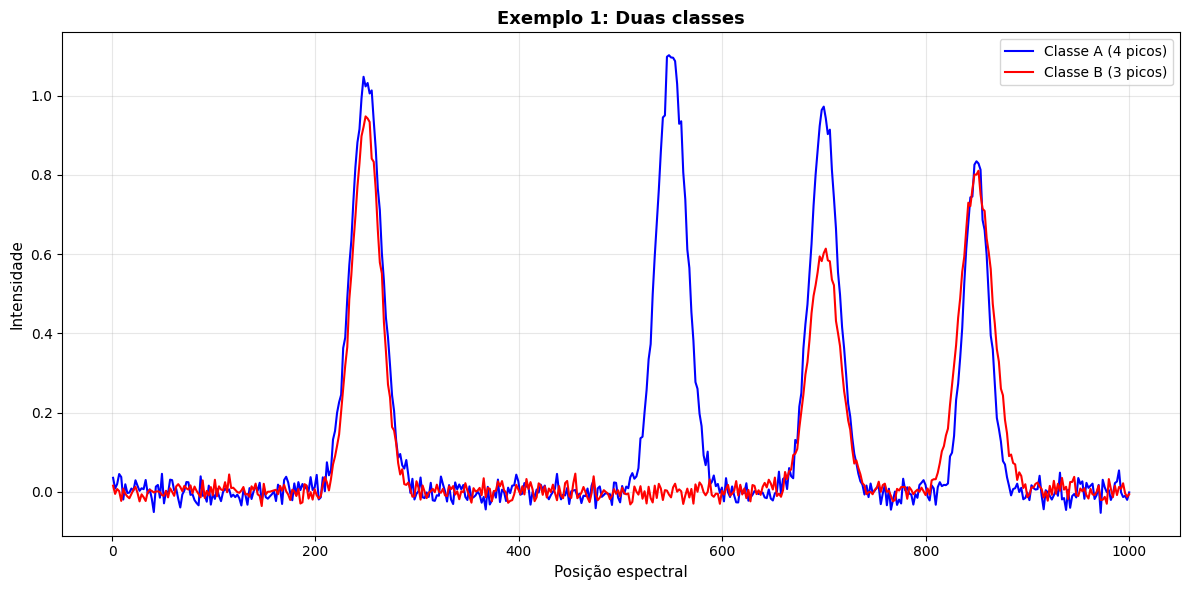

In [3]:
# Exemplo com duas classes

config_2_classes = [
    {
        'nome': 'A',
        'n_amostras': 54,
        'picos': [250, 550, 700, 850],  # 4 picos
        'amp_media': 1.0,
        'larg_media': 15.0,
        'ruido_std': 0.02
    },
    {
        'nome': 'B',
        'n_amostras': 46,
        'picos': [250, 700, 850],  # 3 picos (sem pico em 550)
        'amp_media': 0.8,
        'larg_media': 15.0,
        'ruido_std': 0.015
    }
]

espectros_sinteticos = gerar_dados_espectrais_sinteticos(
    configuracao_classes=config_2_classes,
    n_pontos=500,
    x_min=1,
    x_max=1000,
    seed=0
)

# Visualização
plt.figure(figsize=(12, 6))
idx_A = espectros_sinteticos[espectros_sinteticos['classe'] == 'A'].index[0]
idx_B = espectros_sinteticos[espectros_sinteticos['classe'] == 'B'].index[0]
espectro_A = espectros_sinteticos.iloc[idx_A, 1:].values.astype(float)
espectro_B = espectros_sinteticos.iloc[idx_B, 1:].values.astype(float)
x_vals = espectros_sinteticos.columns[1:].astype(float)

plt.plot(x_vals, espectro_A, label='Classe A (4 picos)', color='blue', linewidth=1.5)
plt.plot(x_vals, espectro_B, label='Classe B (3 picos)', color='red', linewidth=1.5)
plt.xlabel('Posição espectral', fontsize=11)
plt.ylabel('Intensidade', fontsize=11)
plt.title('Exemplo 1: Duas classes', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()